### Import libraries

In [1]:
import torch
import numpy as np
import linear_operator_learning as lol
import matplotlib.pyplot as plt

from pathlib import Path
from huggingface_hub import hf_hub_download
from tqdm.auto import tqdm
from time import perf_counter
from scipy.stats import iqr

from dotenv import load_dotenv
# Assume there's a .env file on the root of the repo where "DATA_PATH" is defined
load_dotenv()

repo_id = "CSML-IIT/encoderops"

### Loading data

In [2]:
from src.data import Lorenz63DataModule
from src.configs import TrainerArgs, Lorenz63DataArgs
from torch.utils.data import DataLoader
from kooplearn.data import traj_to_contexts

ckpt_dir = Path().cwd() / '__ckpt__'

args = TrainerArgs()
data_args = Lorenz63DataArgs(lagtime=1, history_len=0)

datamodule = Lorenz63DataModule(args, data_args)
datamodule.prepare_data()
datamodule.setup("fit")

train_ds = datamodule.train_dataset
test_ds = datamodule.test_dataset
ground_truth = test_ds.data.astype('float32')[1:] # remove first time step since it has no prediction

train_dl = DataLoader(train_ds, batch_size=len(train_ds), shuffle=False)
test_dl = DataLoader(test_ds, batch_size=len(test_ds), shuffle=False)

train_ctxs = traj_to_contexts(train_ds.data.astype('float32'), time_lag=1, backend='numpy')
test_ctxs = traj_to_contexts(test_ds.data.astype('float32'), time_lag=1, backend='numpy')

n_vars = train_ds.data.shape[1]

2025-09-24 19:24:12.895 | INFO     | src.data:__init__:818 - Dataset loaded with 9999 samples and 3 variables.
2025-09-24 19:24:12.911 | INFO     | src.data:__init__:818 - Dataset loaded with 999 samples and 3 variables.
2025-09-24 19:24:12.925 | INFO     | src.data:__init__:818 - Dataset loaded with 999 samples and 3 variables.


## Evaluating models

In [3]:
def RMSE(pred, target):
    return np.sqrt(np.mean((pred - target) ** 2))

def MAE(pred, target):
    return np.mean(np.abs(pred - target))

### Our - Evolution Operator

In [4]:
@torch.no_grad()
def modes(obs_Y: torch.Tensor,emb_X: torch.Tensor, emb_Y: torch.Tensor, reg: float=1e-4):
    cov_X = lol.nn.stats.covariance(emb_X)
    cov_X += torch.eye(cov_X.shape[0], device=cov_X.device) * reg
    cov_Y = lol.nn.stats.covariance(emb_Y)
    cov_XY = lol.nn.stats.covariance(emb_X, emb_Y)
    G = torch.linalg.solve(cov_X, cov_XY)
    print("Computed estimator")
    l, Q = torch.linalg.eig(G) # Q @ torch.diag(l) @ Q^-1 = G
    print("Computed eig decomposition")
    obs_shape = obs_Y.shape[1:]
    print(f"Flattening observable shape {obs_shape}")
    norm = np.sqrt(emb_Y.shape[0])
    coeffs = torch.tensordot(emb_Y.T/norm, obs_Y.view(obs_Y.shape[0], -1)/norm, dims=1)
    print(f"coeffs shape: {coeffs.shape} | min: {coeffs.min():.2f} | max {coeffs.max():.2f} ")
    Z = torch.linalg.solve(cov_Y.cfloat()@Q, coeffs.cfloat())
    print(f"Computed modes, of shape {Z.shape}")
    Z = Z.view(-1, *obs_shape)
    print(f"Reshaped modes to {Z.shape}")
    return l, Q, cov_Y, coeffs

@torch.no_grad()
def transfer_operator(emb_X: torch.Tensor, emb_Y: torch.Tensor, reg: float=1e-4):
    cov_X = lol.nn.stats.covariance(emb_X)
    cov_X += torch.eye(cov_X.shape[0], device=cov_X.device) * reg
    cov_XY = lol.nn.stats.covariance(emb_X, emb_Y)
    G = torch.linalg.solve(cov_X, cov_XY)
    return G

def get_embeddings(model, dl):
    model.eval()
    with torch.no_grad():
        for batch in dl:
            emb_x = model.encoder(batch[0].to(model.device))
            emb_y = model.encoder(batch[1].to(model.device))
    emb_x = model.normalizer(emb_x)
    emb_y = model.normalizer(emb_y)
    obs_x = batch[0].to(model.device)
    obs_y = batch[1].to(model.device)
    emb_x = torch.cat([emb_x, obs_x], dim=-1)
    emb_y = torch.cat([emb_y, obs_y], dim=-1)
    return emb_x, emb_y

In [5]:
def model_validation(model):
    emb_x, emb_y = get_embeddings(model, train_dl)
    emb_x_test, emb_y_test = get_embeddings(model, test_dl)
    T = transfer_operator(emb_x.cpu(), emb_y.cpu(), 1e-5)

    with torch.no_grad():
        for batch in test_dl:
            truth = batch[1].cpu().numpy()

    predictions = emb_x_test.cpu() @ T
    predictions = predictions[:,-3:].numpy()

    rmse = RMSE(predictions, truth)
    mae = MAE(predictions, truth)

    return {'rmse': rmse, 'mae': mae, 'predictions': predictions, 'truth':truth}

In [6]:
from src.model import EvolutionOperator

subdir = "lorenz63/EvolutionOperator_dataopt"
n_models = 20

rmse = []
mae = []
pse = []
predictions = []
for i in np.arange(n_models):
    filename = f"EvOp_rep{i}.pt"
    path_in_repo = f"{subdir}/{filename}"
    try:
        ckpt_path =hf_hub_download(
                repo_id=repo_id,
                filename=path_in_repo,
                repo_type="model")
    except Exception as e:
        print(f"Error downloading {path_in_repo}: {e}")
        continue
    model = EvolutionOperator.load_from_checkpoint(ckpt_path)
    results = model_validation(model)
    predictions.append(results['predictions'])
    rmse.append(results['rmse'])
    mae.append(results['mae'])

print(f'RMSE of Evolution Operator: {np.mean(rmse):.4f} +- {np.std(rmse):.4f}')
print(f'MAE of Evolution Operator: {np.mean(mae):.4f} +- {np.std(mae):.4f}')

RMSE of Evolution Operator: 0.0049 +- 0.0024
MAE of Evolution Operator: 0.0032 +- 0.0024


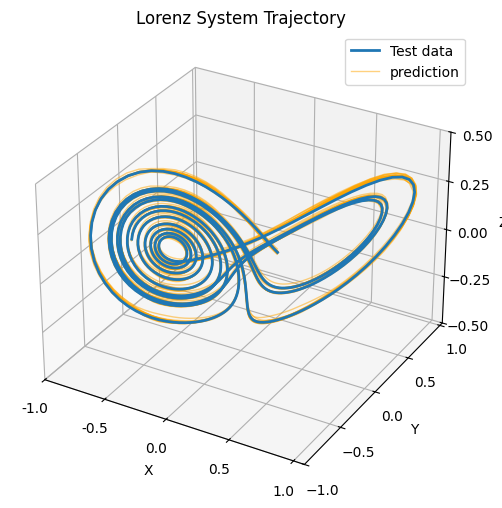

In [7]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

for i, pred in enumerate(predictions):
    if i == 0:
        ax.plot(pred[:,0], pred[:,1], pred[:,2], lw=1, alpha=.5, label='prediction', color='orange')
    else:
        ax.plot(pred[:,0], pred[:,1], pred[:,2], lw=1, alpha=.5, label='_nolegend_', color='orange')
ax.plot(results["truth"][:,0], results["truth"][:,1], results["truth"][:,2], lw=2, label='Test data')
ax.set_title("Lorenz System Trajectory")
ax.set_xlabel("X")
ax.set_xticks(np.linspace(-1,1,5),)
ax.set_xticklabels(np.linspace(-1,1,5))
ax.set_ylabel("Y")
ax.set_yticks(np.linspace(-1,1,5))
ax.set_zlabel("Z")
ax.set_zticks(np.linspace(-.5,.5,5))

plt.legend(['prediction', 'Test data'])
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1])
plt.show()

In [8]:
filename = "EvOp_rep6.pt"
path_in_repo = f"{subdir}/{filename}"
ckpt_path =hf_hub_download(
        repo_id=repo_id,
        filename=path_in_repo,
        repo_type="model")
model = EvolutionOperator.load_from_checkpoint(ckpt_path)
observable = torch.tensor(train_ds.data[:-1].astype('float32'))
model.eval()
with torch.no_grad():
    for batch in train_dl:
        emb_x = model.encoder(batch[0].to(model.device))
        emb_y = model.encoder(batch[1].to(model.device))

emb_x = model.normalizer(emb_x).cpu()
emb_y = model.normalizer(emb_y).cpu()
emb_x_state = torch.cat([emb_x, batch[0]], dim=-1)
emb_y_state = torch.cat([emb_y, batch[1]], dim=-1)

vals, Q, cov_Y, coeffs = modes(observable, emb_x_state, emb_y_state, reg=1e-5)
rfuncs = emb_x_state.to(Q.dtype)@Q
reg_cov_Y = (cov_Y + 1e-5*torch.eye(cov_Y.shape[0], dtype=cov_Y.dtype, device=cov_Y.device)).to(Q.dtype)
lfuncs = torch.linalg.solve(reg_cov_Y@Q, emb_x_state.to(Q.dtype).T).T

Computed estimator
Computed eig decomposition
Flattening observable shape torch.Size([3])
coeffs shape: torch.Size([11, 3]) | min: -0.10 | max 0.29 
Computed modes, of shape torch.Size([11, 3])
Reshaped modes to torch.Size([11, 3])


In [9]:
unique_vals, idx_start = np.unique(np.abs(vals), return_index=True) # returns the unique values and the index of the first occurrence of a value

vals, lfuncs, rfuncs = vals[idx_start], lfuncs[:, idx_start], rfuncs[:, idx_start]
idx_sort = np.argsort(-np.abs(vals))
vals, lfuncs, rfuncs = vals[idx_sort], lfuncs[:, idx_sort], rfuncs[:, idx_sort]

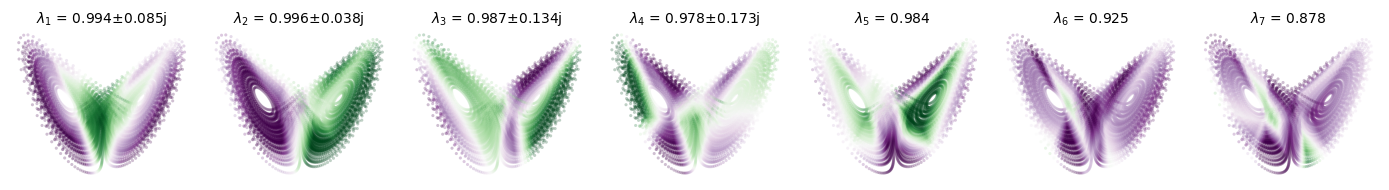

In [10]:
fig, axs = plt.subplots(ncols=len(vals), figsize=(len(vals)*2, 2))

for i, ax in enumerate(axs):
    efun = rfuncs[:, i].real
    vmax = np.abs(efun).max()/2
    ax.scatter(train_ds.data[1:,0],train_ds.data[1:,2],c=efun,s=5, alpha=.25, cmap='PRGn', vmax=vmax, vmin=-vmax, lw=0)
    ax.set_xticks([])
    ax.set_yticks([])

    # Remove all ticks and spines (axes borders)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_frame_on(False)  # Optional: removes bounding box in some cases
    if vals[i].imag != 0:
        ax.set_title(f'$\lambda_{i+1}$ = {vals[i].real:.3f}$\pm${vals[i].imag:.3f}j', fontsize=10, pad=0)
    else:
        ax.set_title(f'$\lambda_{i+1}$ = {vals[i].real:.3f}', fontsize=10, pad=0)

plt.tight_layout()
plt.show()
fig.savefig("figures/Our_eigenfunctions.svg", dpi=300, transparent=True)
fig.savefig("figures/Our_eigenfunctions.png", dpi=300, transparent=True)

In [11]:
import wandb

# Initialize the API
api = wandb.Api()

# Replace with your project path: "entity/project"
project_path = "csml/encoderops-lorenz63"

# Get all runs from the project
runs = api.runs(project_path)

In [12]:
n_models = 20

timings = []
for seed in np.arange(n_models):
    run_name = f"EvOp_rep{seed}"

    # Find the run with that name
    runs = api.runs(project_path)
    target_run = None
    for run in runs:
        if run.name == run_name:
            target_run = run
            break

    timings.append(target_run.history(keys=['epoch_time']).values[:,-1])

timings = np.array(timings) * 1000  # Convert to milliseconds
print(f"Evolution Operator fit time: {np.mean(timings):.2f} ms +- {np.std(timings):.2f} ms")
IQR = iqr(timings)
print(f"Evolution Operator fit time: {np.median(timings):.2f} ms; IQR: {IQR:.2f} ms")

Evolution Operator fit time: 181.09 ms +- 40.87 ms
Evolution Operator fit time: 176.96 ms; IQR: 1.96 ms


### Linear Ordinary Least Squares (LinLS)

In [13]:
from kooplearn.models import Linear

linear_model = Linear(reduced_rank = False, rank= n_vars).fit(train_ctxs)
pred = (linear_model.predict(test_ctxs, t=1)).reshape(-1, n_vars)
rmse = RMSE(pred, ground_truth)
mae = MAE(pred, ground_truth)
print(f'RMSE of linear model: {rmse:.4f}')
print(f'MAE of linear model: {mae:.4f}')

RMSE of linear model: 0.0129
MAE of linear model: 0.0084


In [14]:
nrep = 100
timings = []
for i in range(nrep):
    start_time = perf_counter()
    linear_model = Linear(reduced_rank = False, rank= n_vars).fit(train_ctxs)
    timings.append((perf_counter() - start_time))  # Convert to milliseconds

timings = np.array(timings) * 1000  # Convert to milliseconds
print(f"Linear model fit time: {np.mean(timings):.2f} ms +- {np.std(timings):.2f} ms")
IQR = iqr(timings)
print(f"Linear model fit time: {np.median(timings):.2f} ms; IQR: {IQR:.2f} ms")

Linear model fit time: 0.50 ms +- 0.09 ms
Linear model fit time: 0.49 ms; IQR: 0.04 ms


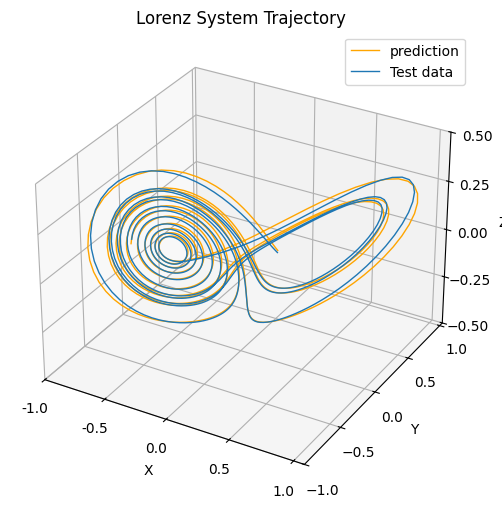

In [15]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot(pred[:,0], pred[:,1], pred[:,2], lw=1, label='prediction', color='orange')
ax.plot(ground_truth[:,0], ground_truth[:,1], ground_truth[:,2], lw=1, label='Test data')
ax.set_title("Lorenz System Trajectory")
ax.set_xlabel("X")
ax.set_xticks(np.linspace(-1,1,5),)
ax.set_xticklabels(np.linspace(-1,1,5))
ax.set_ylabel("Y")
ax.set_yticks(np.linspace(-1,1,5))
ax.set_zlabel("Z")
ax.set_zticks(np.linspace(-.5,.5,5))

plt.legend()
plt.show()

In [16]:
vals, lfuncs, rfuncs = linear_model.eig(eval_right_on=train_ctxs, eval_left_on=train_ctxs)
unique_vals, idx_start = np.unique(np.abs(vals), return_index=True) # returns the unique values and the index of the first occurrence of a value

vals, lfuncs, rfuncs = vals[idx_start], lfuncs[:, idx_start], rfuncs[:, idx_start]
idx_sort = np.argsort(-np.abs(vals))
vals, lfuncs, rfuncs = vals[idx_sort], lfuncs[:, idx_sort], rfuncs[:, idx_sort]

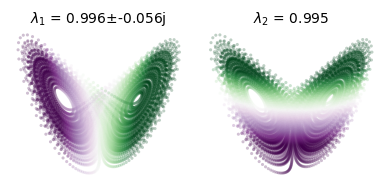

In [17]:
fig, axs = plt.subplots(ncols=2, figsize=(4, 2))

for i, ax in enumerate(axs):
    efun = rfuncs[:, i].real
    vmax = np.abs(efun).max()/2
    ax.scatter(train_ds.data[1:,0],train_ds.data[1:,2],c=efun,s=5, alpha=.25, cmap='PRGn', vmax=vmax, vmin=-vmax, lw=0)
    ax.set_xticks([])
    ax.set_yticks([])

    # Remove all ticks and spines (axes borders)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_frame_on(False)  # Optional: removes bounding box in some cases
    if vals[i].imag != 0:
        ax.set_title(f'$\lambda_{i+1}$ = {vals[i].real:.3f}$\pm${vals[i].imag:.3f}j', fontsize=10, pad=0)
    else:
        ax.set_title(f'$\lambda_{i+1}$ = {vals[i].real:.3f}', fontsize=10, pad=0)

plt.tight_layout()
plt.show()
fig.savefig("figures/LinLS_eigenfunctions.svg", dpi=300, transparent=True)
fig.savefig("figures/LinLS_eigenfunctions.png", dpi=300, transparent=True)

### Kernel Ridge Regression (KRR)

In [18]:
from kooplearn.models import Kernel
from scipy.spatial.distance import pdist
from sklearn.gaussian_process.kernels import RBF

rank = 11
tikhonov_reg = 1e-6
reduced_rank = True
n_rep = 20

# Instantiang the RBF kernel and its length scale as the median of the pairwise distances of the dataset
data_pdist = pdist(train_ds.data)
kernel = RBF(length_scale=np.quantile(data_pdist, 0.5))

train_ctxs = traj_to_contexts(train_ds.data.astype('float32'), time_lag=1, backend='numpy')
test_ctxs = traj_to_contexts(test_ds.data.astype('float32'), time_lag=1, backend='numpy')

timings = []
rmse = []
mae = []
for i in tqdm(range(n_rep)):
    start_time = perf_counter()
    KRR = Kernel(kernel=kernel, reduced_rank=reduced_rank, tikhonov_reg=tikhonov_reg, rank = rank).fit(train_ctxs)
    # KRR = Kernel(kernel=kernel, tikhonov_reg=tikhonov_reg, rank = None).fit(train_ctxs)
    timings.append((perf_counter() - start_time))
    pred = (KRR.predict(test_ctxs, t=1)).reshape(-1, n_vars)
    rmse.append(RMSE(pred, ground_truth))
    mae.append(MAE(pred, ground_truth))

timings = np.array(timings) * 1000  # Convert to milliseconds
print(f"Kernel Ridge Regression fit time: {np.mean(timings):.2f} ms +- {np.std(timings):.2f} ms")
IQR = iqr(timings)
print(f"Kernel Ridge Regression fit time: {np.median(timings):.2f} ms; IQR: {IQR:.2f} ms")
print(f'RMSE of KRR model: {np.mean(rmse):.4f} +- {np.std(rmse):.4f}')
print(f'MAE of KRR model: {np.mean(mae):.4f} +- {np.std(mae):.4f}')

  0%|          | 0/20 [00:00<?, ?it/s]

Kernel Ridge Regression fit time: 25056.67 ms +- 36.62 ms
Kernel Ridge Regression fit time: 25061.49 ms; IQR: 49.34 ms
RMSE of KRR model: 0.0210 +- 0.0000
MAE of KRR model: 0.0127 +- 0.0000


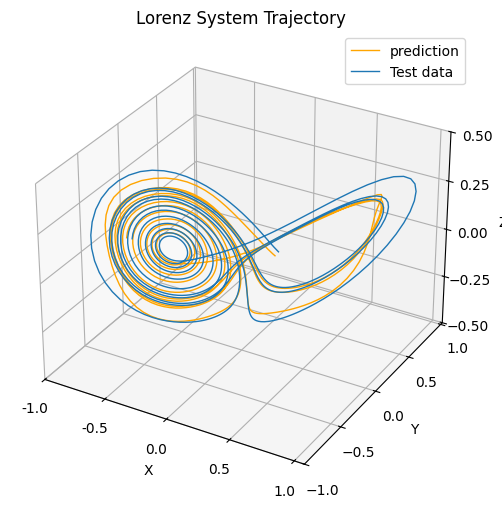

In [19]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot(pred[:,0], pred[:,1], pred[:,2], lw=1, label='prediction', color='orange')
ax.plot(ground_truth[:,0], ground_truth[:,1], ground_truth[:,2], lw=1, label='Test data')
ax.set_title("Lorenz System Trajectory")
ax.set_xlabel("X")
ax.set_xticks(np.linspace(-1,1,5),)
ax.set_xticklabels(np.linspace(-1,1,5))
ax.set_ylabel("Y")
ax.set_yticks(np.linspace(-1,1,5))
ax.set_zlabel("Z")
ax.set_zticks(np.linspace(-.5,.5,5))

plt.legend()
plt.show()

In [20]:
vals, lfuncs, rfuncs = KRR.eig(eval_right_on=train_ctxs, eval_left_on=train_ctxs)
unique_vals, idx_start = np.unique(np.abs(vals), return_index=True) # returns the unique values and the index of the first occurrence of a value

vals, lfuncs, rfuncs = vals[idx_start], lfuncs[:, idx_start], rfuncs[:, idx_start]
idx_sort = np.argsort(-np.abs(vals))
vals, lfuncs, rfuncs = vals[idx_sort], lfuncs[:, idx_sort], rfuncs[:, idx_sort]

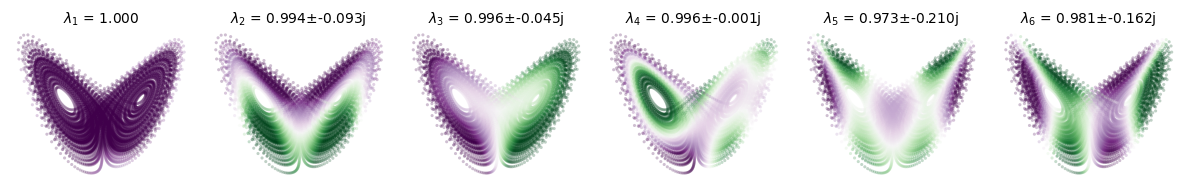

In [21]:
fig, axs = plt.subplots(ncols=len(vals), figsize=(len(vals)*2, 2))

for i, ax in enumerate(axs):
    efun = rfuncs[:, i].real
    vmax = np.abs(efun).max()/2
    ax.scatter(train_ds.data[1:,0],train_ds.data[1:,2],c=efun,s=5, alpha=.25, cmap='PRGn', vmax=vmax, vmin=-vmax, lw=0)
    ax.set_xticks([])
    ax.set_yticks([])

    # Remove all ticks and spines (axes borders)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_frame_on(False)  # Optional: removes bounding box in some cases
    if vals[i].imag != 0:
        ax.set_title(f'$\lambda_{i+1}$ = {vals[i].real:.3f}$\pm${vals[i].imag:.3f}j', fontsize=10, pad=0)
    else:
        ax.set_title(f'$\lambda_{i+1}$ = {vals[i].real:.3f}', fontsize=10, pad=0)

plt.tight_layout()
plt.show()
fig.savefig("figures/KRR_eigenfunctions.svg", dpi=300, transparent=True)
fig.savefig("figures/KRR_eigenfunctions.png", dpi=300, transparent=True)

### VAMPNets

In [22]:
from kooplearn.models import Nonlinear
from kooplearn.models.feature_maps.nn import NNFeatureMap
from linear_operator_learning.nn import MLP

class MLPEncoder(torch.nn.Module):
    def __init__(
        self,
        input_shape,
        n_hidden,
        layer_size,
        output_shape,
        dropout=0.0,
        activation=torch.nn.ReLU,
        iterative_whitening=False,
        bias=True,
    ):
        super(MLPEncoder, self).__init__()

        self.encoder = MLP(
            input_shape=input_shape,
            n_hidden=n_hidden,
            layer_size=layer_size,
            output_shape=output_shape,
            dropout=dropout,
            activation=activation,
            iterative_whitening=iterative_whitening,
            bias=bias,
        )
        
    def forward(self, x):
        x_enc = self.encoder(x)
        x_enc = torch.cat([x_enc, x], dim=-1)
        return x_enc

In [23]:
latent_dims = 8
def model_validation(feature_map):
    nn_model = Nonlinear(feature_map, reduced_rank = False, rank=latent_dims+n_vars).fit(train_ctxs)
    predictions = (nn_model.predict(test_ctxs, t=1)).reshape(-1, n_vars)
    rmse = RMSE(predictions, ground_truth)
    mae = MAE(predictions, ground_truth)
    return {'rmse': rmse, 'mae': mae, 'predictions': predictions}

In [24]:
subdir = "lorenz63/VAMPNets"
n_models = 20

rmse = []
mae = []
predictions = []
for i in range(n_models):
    filename = f"VAMPNets_rep{i}.pt"
    path_in_repo = f"{subdir}/{filename}"
    ckpt_path =hf_hub_download(
            repo_id=repo_id,
            filename=path_in_repo,
            repo_type="model")
    feature_map = NNFeatureMap.load(ckpt_path)
    results = model_validation(feature_map)
    predictions.append(results['predictions'])
    rmse.append(results['rmse'])
    mae.append(results['mae'])
print(f'RMSE of VAMPNets: {np.mean(rmse):.4f} +- {np.std(rmse):.4f}')
print(f'MAE of VAMPNets: {np.mean(mae):.4f} +- {np.std(mae):.4f}')

The rank attribute has been updated to 7.
Consider decreasing the rank parameter.
The rank attribute has been updated to 7.
Consider decreasing the rank parameter.
The rank attribute has been updated to 5.
Consider decreasing the rank parameter.
The rank attribute has been updated to 8.
Consider decreasing the rank parameter.
The rank attribute has been updated to 7.
Consider decreasing the rank parameter.
The rank attribute has been updated to 6.
Consider decreasing the rank parameter.
The rank attribute has been updated to 7.
Consider decreasing the rank parameter.
The rank attribute has been updated to 7.
Consider decreasing the rank parameter.
The rank attribute has been updated to 7.
Consider decreasing the rank parameter.
The rank attribute has been updated to 6.
Consider decreasing the rank parameter.
The rank attribute has been updated to 7.
Consider decreasing the rank parameter.
The rank attribute has been updated to 8.
Consider decreasing the rank parameter.
The rank attribu

RMSE of VAMPNets: 0.0078 +- 0.0012
MAE of VAMPNets: 0.0046 +- 0.0008


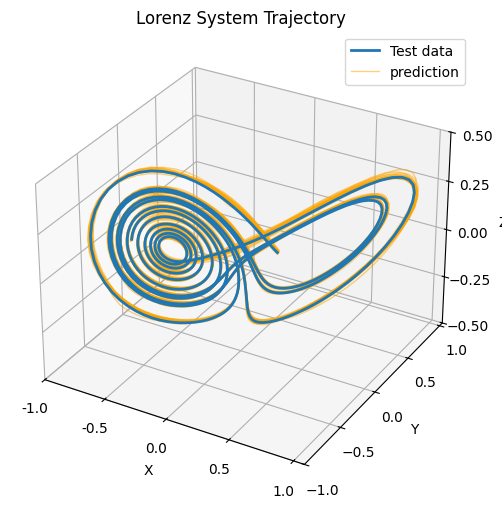

In [25]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

for i, pred in enumerate(predictions):
    if i == 0:
        ax.plot(pred[:,0], pred[:,1], pred[:,2], lw=1, alpha=.5, label='prediction', color='orange')
    else:
        ax.plot(pred[:,0], pred[:,1], pred[:,2], lw=1, alpha=.5, label='_nolegend_', color='orange')
ax.plot(ground_truth[:,0], ground_truth[:,1], ground_truth[:,2], lw=2, label='Test data')
ax.set_title("Lorenz System Trajectory")
ax.set_xlabel("X")
ax.set_xticks(np.linspace(-1,1,5),)
ax.set_xticklabels(np.linspace(-1,1,5))
ax.set_ylabel("Y")
ax.set_yticks(np.linspace(-1,1,5))
ax.set_zlabel("Z")
ax.set_zticks(np.linspace(-.5,.5,5))

plt.legend(['prediction', 'Test data'])
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1])
plt.show()

In [26]:
nn_model = Nonlinear(feature_map, reduced_rank = False, rank=latent_dims+n_vars).fit(train_ctxs)
vals, lfuncs, rfuncs = nn_model.eig(eval_right_on=train_ctxs, eval_left_on=train_ctxs)
unique_vals, idx_start = np.unique(np.abs(vals), return_index=True) # returns the unique values and the index of the first occurrence of a value

vals, lfuncs, rfuncs = vals[idx_start], lfuncs[:, idx_start], rfuncs[:, idx_start]
idx_sort = np.argsort(-np.abs(vals))
vals, lfuncs, rfuncs = vals[idx_sort], lfuncs[:, idx_sort], rfuncs[:, idx_sort]

The rank attribute has been updated to 8.
Consider decreasing the rank parameter.


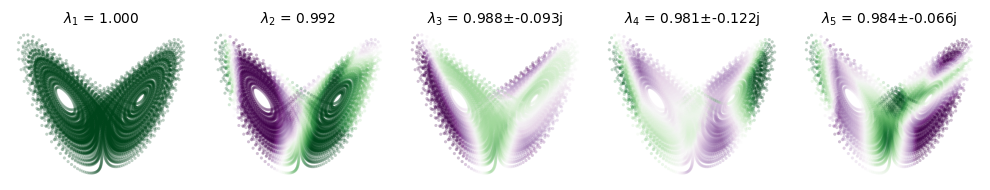

In [27]:
fig, axs = plt.subplots(ncols=len(vals), figsize=(len(vals)*2, 2))

for i, ax in enumerate(axs):
    efun = rfuncs[:, i].real
    vmax = np.abs(efun).max()/2
    ax.scatter(train_ds.data[1:,0],train_ds.data[1:,2],c=efun,s=5, alpha=.25, cmap='PRGn', vmax=vmax, vmin=-vmax, lw=0)
    ax.set_xticks([])
    ax.set_yticks([])

    # Remove all ticks and spines (axes borders)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_frame_on(False)  # Optional: removes bounding box in some cases
    if vals[i].imag != 0:
        ax.set_title(f'$\lambda_{i+1}$ = {vals[i].real:.3f}$\pm${vals[i].imag:.3f}j', fontsize=10, pad=0)
    else:
        ax.set_title(f'$\lambda_{i+1}$ = {vals[i].real:.3f}', fontsize=10, pad=0)

plt.tight_layout()
plt.show()
fig.savefig("figures/VAMPNets_eigenfunctions.svg", dpi=300, transparent=True)
fig.savefig("figures/VAMPNets_eigenfunctions.png", dpi=300, transparent=True)

In [28]:
import wandb

# Initialize the API
api = wandb.Api()

# Replace with your project path: "entity/project"
project_path = "csml/encoderops-lorenz63"

# Get all runs from the project
runs = api.runs(project_path)

In [29]:
n_models = 20

timings = []
for seed in np.arange(n_models):
    run_name = f"VAMPNets1000_rep{seed}"

    # Find the run with that name
    runs = api.runs(project_path)
    target_run = None
    for run in runs:
        if run.name == run_name:
            target_run = run
            break

    timings.append(target_run.history(keys=['epoch_time']).values[:,-1])

timings = np.array(timings) * 1000  # Convert to milliseconds
print(f"VAMPNets fit time: {np.mean(timings):.2f} ms +- {np.std(timings):.2f} ms")
IQR = iqr(timings)
print(f"VAMPNets fit time: {np.median(timings):.2f} ms; IQR: {IQR:.2f} ms")


VAMPNets fit time: 164.50 ms +- 4.17 ms
VAMPNets fit time: 164.24 ms; IQR: 2.31 ms


### DPNets

In [30]:
from kooplearn.models import Nonlinear
from kooplearn.models.feature_maps.nn import NNFeatureMap
from linear_operator_learning.nn import MLP

class MLPEncoder(torch.nn.Module):
    def __init__(
        self,
        input_shape,
        n_hidden,
        layer_size,
        output_shape,
        dropout=0.0,
        activation=torch.nn.ReLU,
        iterative_whitening=False,
        bias=True,
    ):
        super(MLPEncoder, self).__init__()

        self.encoder = MLP(
            input_shape=input_shape,
            n_hidden=n_hidden,
            layer_size=layer_size,
            output_shape=output_shape,
            dropout=dropout,
            activation=activation,
            iterative_whitening=iterative_whitening,
            bias=bias,
        )
        
    def forward(self, x):
        x_enc = self.encoder(x)
        x_enc = torch.cat([x_enc, x], dim=-1)
        return x_enc

In [31]:
latent_dims = 8
def model_validation(feature_map):
    nn_model = Nonlinear(feature_map, reduced_rank = False, rank=latent_dims+n_vars).fit(train_ctxs)
    predictions = (nn_model.predict(test_ctxs, t=1)).reshape(-1, n_vars)
    rmse = RMSE(predictions, ground_truth)
    mae = MAE(predictions, ground_truth)
    return {'rmse': rmse, 'mae': mae, 'predictions': predictions}

In [32]:
subdir = "lorenz63/DPNets"
n_models = 20

rmse = []
mae = []
predictions = []
for i in np.arange(n_models):
    filename = f"DPNets_rep{i}.pt"
    path_in_repo = f"{subdir}/{filename}"
    ckpt_path =hf_hub_download(
            repo_id=repo_id,
            filename=path_in_repo,
            repo_type="model")
    feature_map = NNFeatureMap.load(ckpt_path)
    results = model_validation(feature_map)
    predictions.append(results['predictions'])
    rmse.append(results['rmse'])
    mae.append(results['mae'])
print(f'RMSE of DPNets: {np.mean(rmse):.4f} +- {np.std(rmse):.4f}')
print(f'MAE of DPNets: {np.mean(mae):.4f} +- {np.std(mae):.4f}')

RMSE of DPNets: 0.0058 +- 0.0011
MAE of DPNets: 0.0036 +- 0.0008


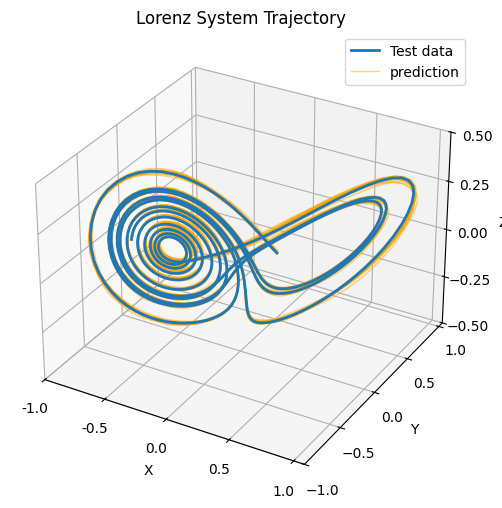

In [33]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

for i, pred in enumerate(predictions):
    if i == 0:
        ax.plot(pred[:,0], pred[:,1], pred[:,2], lw=1, alpha=.5, label='prediction', color='orange')
    else:
        ax.plot(pred[:,0], pred[:,1], pred[:,2], lw=1, alpha=.5, label='_nolegend_', color='orange')
ax.plot(ground_truth[:,0], ground_truth[:,1], ground_truth[:,2], lw=2, label='Test data')
ax.set_title("Lorenz System Trajectory")
ax.set_xlabel("X")
ax.set_xticks(np.linspace(-1,1,5),)
ax.set_xticklabels(np.linspace(-1,1,5))
ax.set_ylabel("Y")
ax.set_yticks(np.linspace(-1,1,5))
ax.set_zlabel("Z")
ax.set_zticks(np.linspace(-.5,.5,5))

plt.legend(['prediction', 'Test data'])
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1])
plt.show()

In [34]:
nn_model = Nonlinear(feature_map, reduced_rank = False, rank=latent_dims+n_vars).fit(train_ctxs)
vals, lfuncs, rfuncs = nn_model.eig(eval_right_on=train_ctxs, eval_left_on=train_ctxs)
unique_vals, idx_start = np.unique(np.abs(vals), return_index=True) # returns the unique values and the index of the first occurrence of a value

vals, lfuncs, rfuncs = vals[idx_start], lfuncs[:, idx_start], rfuncs[:, idx_start]
idx_sort = np.argsort(-np.abs(vals))
vals, lfuncs, rfuncs = vals[idx_sort], lfuncs[:, idx_sort], rfuncs[:, idx_sort]

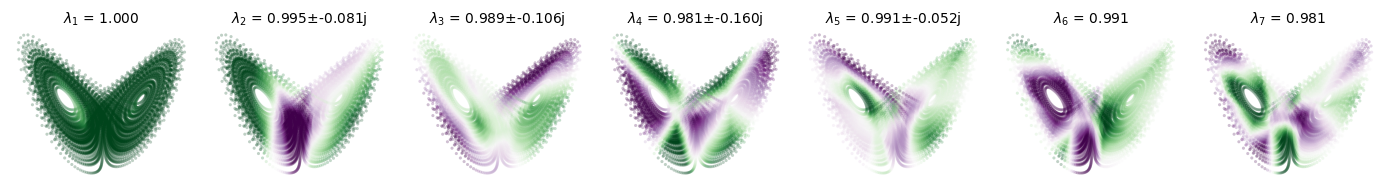

In [35]:
fig, axs = plt.subplots(ncols=len(vals), figsize=(len(vals)*2, 2))

for i, ax in enumerate(axs):
    efun = rfuncs[:, i].real
    vmax = np.abs(efun).max()/2
    ax.scatter(train_ds.data[1:,0],train_ds.data[1:,2],c=efun,s=5, alpha=.25, cmap='PRGn', vmax=vmax, vmin=-vmax, lw=0)
    ax.set_xticks([])
    ax.set_yticks([])

    # Remove all ticks and spines (axes borders)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_frame_on(False)  # Optional: removes bounding box in some cases
    if vals[i].imag != 0:
        ax.set_title(f'$\lambda_{i+1}$ = {vals[i].real:.3f}$\pm${vals[i].imag:.3f}j', fontsize=10, pad=0)
    else:
        ax.set_title(f'$\lambda_{i+1}$ = {vals[i].real:.3f}', fontsize=10, pad=0)

plt.tight_layout()
plt.show()
fig.savefig("figures/DPNets_eigenfunctions.svg", dpi=300, transparent=True)
fig.savefig("figures/DPNets_eigenfunctions.png", dpi=300, transparent=True)

In [36]:
n_models = 20

timings = []
for seed in np.arange(n_models):
    run_name = f"DPNets_rep{seed}"

    # Find the run with that name
    runs = api.runs(project_path)
    target_run = None
    for run in runs:
        if run.name == run_name:
            target_run = run
            break

    timings.append(target_run.history(keys=['epoch_time']).values[:,-1])

timings = np.array(timings) * 1000  # Convert to milliseconds
print(f"DPNets fit time: {np.mean(timings):.2f} ms +- {np.std(timings):.2f} ms")
IQR = iqr(timings)
print(f"DPNets fit time: {np.median(timings):.2f} ms; IQR: {IQR:.2f} ms")

DPNets fit time: 190.74 ms +- 41.46 ms
DPNets fit time: 185.55 ms; IQR: 2.39 ms


### Dynamic Autoencoder

In [37]:
from exps.lorenz63.dae import DynamicAE
from exps.lorenz63.trainer_DAE import MLPEncoder, MLPDecoder

In [38]:
from kooplearn.models.ae.utils import encode_contexts
from kooplearn.nn.data import collate_context_dataset
from torch import nn

def recompute_evolution_operator(feature_map, train_ctxs):
    train_dl = DataLoader(
            train_ctxs,
            batch_size = len(train_ctxs),
            shuffle=False,
            collate_fn=collate_context_dataset,
            num_workers=1,
            )

    for batch in train_dl:
        encoded_batch = encode_contexts(batch, feature_map.lightning_module.encoder)

    emb_X = encoded_batch.data[:, 0, ...]
    emb_Y = encoded_batch.data[:, 1, ...]
    K = (torch.linalg.lstsq(emb_X, emb_Y).solution).T

    feature_map.lightning_module.evolution_operator = nn.Parameter(K)

    return feature_map

def model_validation(model):
    predictions = (model.predict(test_ctxs, t=1)).reshape(-1, n_vars)
    rmse = RMSE(predictions, ground_truth)
    mae = MAE(predictions, ground_truth)
    return {'rmse': rmse, 'mae': mae, 'predictions': predictions, 'truth': ground_truth}

In [39]:
subdir = "lorenz63/DAE"
n_models = 20

rmse = []
mae = []
predictions = []
for i in range(n_models):
    filename = f"DAE_rep{i}.pt"
    path_in_repo = f"{subdir}/{filename}"
    ckpt_path =hf_hub_download(
            repo_id=repo_id,
            filename=path_in_repo,
            repo_type="model")
    feature_map = DynamicAE.load(ckpt_path)
    feature_map = recompute_evolution_operator(feature_map, train_ctxs)
    results = model_validation(feature_map)
    predictions.append(results['predictions'])
    rmse.append(results['rmse'])
    mae.append(results['mae'])
print(f'RMSE of DAE: {np.mean(rmse):.4f} +- {np.std(rmse):.4f}')
print(f'MAE of DAE: {np.mean(mae):.4f} +- {np.std(mae):.4f}')

RMSE of DAE: 0.0077 +- 0.0012
MAE of DAE: 0.0056 +- 0.0008


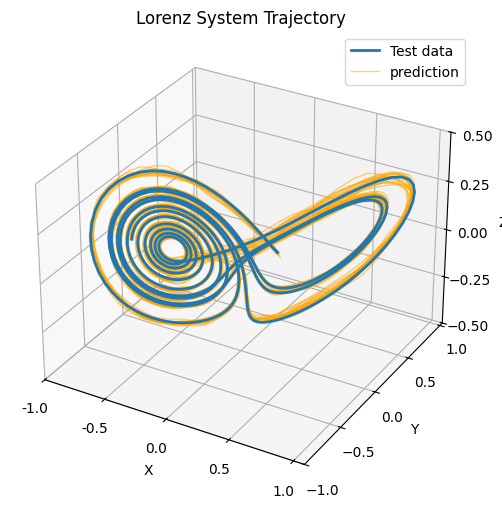

In [40]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

for i, pred in enumerate(predictions):
    if i == 0:
        ax.plot(pred[:,0], pred[:,1], pred[:,2], lw=1, alpha=.5, label='prediction', color='orange')
    else:
        ax.plot(pred[:,0], pred[:,1], pred[:,2], lw=1, alpha=.5, label='_nolegend_', color='orange')
ax.plot(ground_truth[:,0], ground_truth[:,1], ground_truth[:,2], lw=2, label='Test data')
ax.set_title("Lorenz System Trajectory")
ax.set_xlabel("X")
ax.set_xticks(np.linspace(-1,1,5),)
ax.set_xticklabels(np.linspace(-1,1,5))
ax.set_ylabel("Y")
ax.set_yticks(np.linspace(-1,1,5))
ax.set_zlabel("Z")
ax.set_zticks(np.linspace(-.5,.5,5))

plt.legend(['prediction', 'Test data'])
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1])
plt.show()

In [41]:
vals, lfuncs, rfuncs = feature_map.eig(eval_right_on=train_ctxs, eval_left_on=train_ctxs)
unique_vals, idx_start = np.unique(np.abs(vals), return_index=True) # returns the unique values and the index of the first occurrence of a value

vals, lfuncs, rfuncs = vals[idx_start], lfuncs[:, idx_start], rfuncs[:, idx_start]
idx_sort = np.argsort(-np.abs(vals))
vals, lfuncs, rfuncs = vals[idx_sort], lfuncs[:, idx_sort], rfuncs[:, idx_sort]

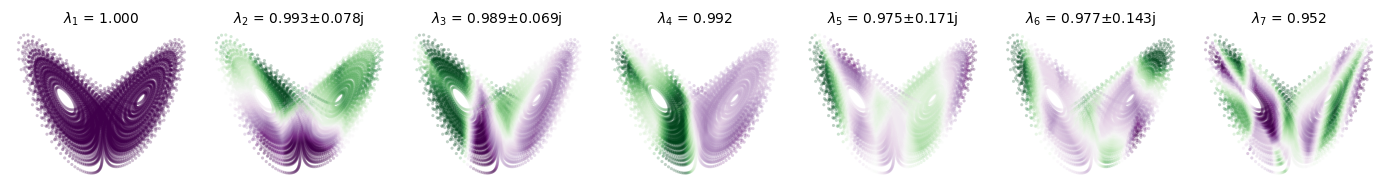

In [42]:
fig, axs = plt.subplots(ncols=len(vals), figsize=(len(vals)*2, 2))

for i, ax in enumerate(axs):
    efun = rfuncs[:, i].real
    vmax = np.abs(efun).max()/2
    ax.scatter(train_ds.data[1:,0],train_ds.data[1:,2],c=efun,s=5, alpha=.25, cmap='PRGn', vmax=vmax, vmin=-vmax, lw=0)
    ax.set_xticks([])
    ax.set_yticks([])

    # Remove all ticks and spines (axes borders)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_frame_on(False)  # Optional: removes bounding box in some cases
    if vals[i].imag != 0:
        ax.set_title(f'$\lambda_{i+1}$ = {vals[i].real:.3f}$\pm${vals[i].imag:.3f}j', fontsize=10, pad=0)
    else:
        ax.set_title(f'$\lambda_{i+1}$ = {vals[i].real:.3f}', fontsize=10, pad=0)

plt.tight_layout()
plt.show()
fig.savefig("figures/DAE_eigenfunctions.svg", dpi=300, transparent=True)
fig.savefig("figures/DAE_eigenfunctions.png", dpi=300, transparent=True)

In [43]:
n_models = 20

timings = []
for seed in np.arange(n_models):
    run_name = f"DAE_rep{seed}"

    # Find the run with that name
    runs = api.runs(project_path)
    target_run = None
    for run in runs:
        if run.name == run_name:
            target_run = run
            break

    timings.append(target_run.history(keys=['epoch_time']).values[:,-1])

timings = np.array(timings) * 1000  # Convert to milliseconds
print(f"DAE fit time: {np.mean(timings):.2f} ms +- {np.std(timings):.2f} ms")
IQR = iqr(timings)
print(f"DAE fit time: {np.median(timings):.2f} ms; IQR: {IQR:.2f} ms")

DAE fit time: 166.82 ms +- 9.04 ms
DAE fit time: 165.81 ms; IQR: 1.92 ms


### Consistent Autoencoder

In [44]:
from exps.lorenz63.cae import ConsistentAE
from exps.lorenz63.trainer_CAE import MLPEncoder, MLPDecoder

In [45]:
subdir = "lorenz63/CAE"
n_models = 20

rmse = []
mae = []
predictions = []
for i in range(n_models):
    filename = f"CAE_rep{i}.pt"
    path_in_repo = f"{subdir}/{filename}"
    ckpt_path =hf_hub_download(
            repo_id=repo_id,
            filename=path_in_repo,
            repo_type="model")
    feature_map = ConsistentAE.load(ckpt_path)
    feature_map = recompute_evolution_operator(feature_map, train_ctxs)
    results = model_validation(feature_map)
    predictions.append(results['predictions'])
    rmse.append(results['rmse'])
    mae.append(results['mae'])
print(f'RMSE of CAE: {np.mean(rmse):.4f} +- {np.std(rmse):.4f}')
print(f'MAE of CAE: {np.mean(mae):.4f} +- {np.std(mae):.4f}')

RMSE of CAE: 0.0258 +- 0.0019
MAE of CAE: 0.0195 +- 0.0014


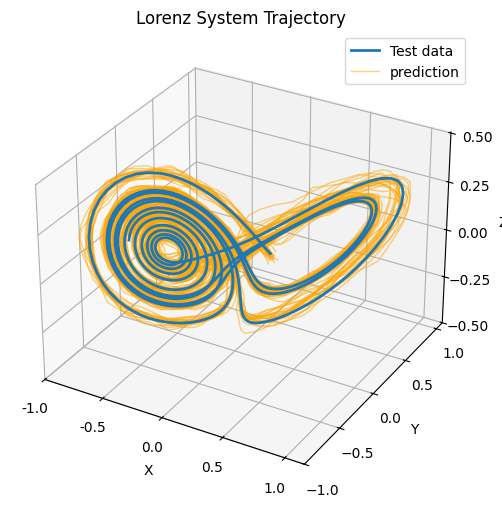

In [46]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

for i, pred in enumerate(predictions):
    if i == 0:
        ax.plot(pred[:,0], pred[:,1], pred[:,2], lw=1, alpha=.5, label='prediction', color='orange')
    else:
        ax.plot(pred[:,0], pred[:,1], pred[:,2], lw=1, alpha=.5, label='_nolegend_', color='orange')
ax.plot(ground_truth[:,0], ground_truth[:,1], ground_truth[:,2], lw=2, label='Test data')
ax.set_title("Lorenz System Trajectory")
ax.set_xlabel("X")
ax.set_xticks(np.linspace(-1,1,5),)
ax.set_xticklabels(np.linspace(-1,1,5))
ax.set_ylabel("Y")
ax.set_yticks(np.linspace(-1,1,5))
ax.set_zlabel("Z")
ax.set_zticks(np.linspace(-.5,.5,5))

plt.legend(['prediction', 'Test data'])
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1])
plt.show()

In [47]:
vals, lfuncs, rfuncs = feature_map.eig(eval_right_on=train_ctxs, eval_left_on=train_ctxs)
unique_vals, idx_start = np.unique(np.abs(vals), return_index=True) # returns the unique values and the index of the first occurrence of a value

vals, lfuncs, rfuncs = vals[idx_start], lfuncs[:, idx_start], rfuncs[:, idx_start]
idx_sort = np.argsort(-np.abs(vals))
vals, lfuncs, rfuncs = vals[idx_sort], lfuncs[:, idx_sort], rfuncs[:, idx_sort]

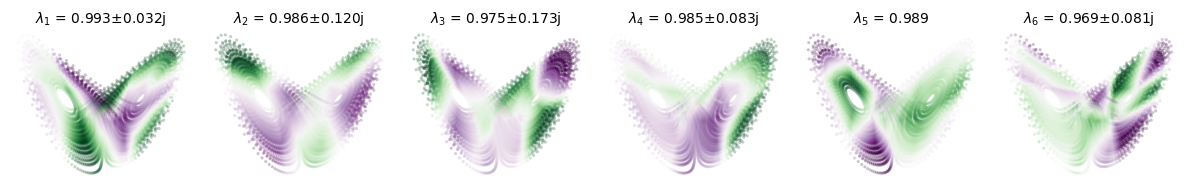

In [48]:
fig, axs = plt.subplots(ncols=len(vals), figsize=(len(vals)*2, 2))

for i, ax in enumerate(axs):
    efun = rfuncs[:, i].real
    vmax = np.abs(efun).max()/2
    ax.scatter(train_ds.data[1:,0],train_ds.data[1:,2],c=efun,s=5, alpha=.25, cmap='PRGn', vmax=vmax, vmin=-vmax, lw=0)
    ax.set_xticks([])
    ax.set_yticks([])

    # Remove all ticks and spines (axes borders)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_frame_on(False)  # Optional: removes bounding box in some cases
    if vals[i].imag != 0:
        ax.set_title(f'$\lambda_{i+1}$ = {vals[i].real:.3f}$\pm${vals[i].imag:.3f}j', fontsize=10, pad=0)
    else:
        ax.set_title(f'$\lambda_{i+1}$ = {vals[i].real:.3f}', fontsize=10, pad=0)

plt.tight_layout()
plt.show()
fig.savefig("figures/CAE_eigenfunctions.svg", dpi=300, transparent=True)
fig.savefig("figures/CAE_eigenfunctions.png", dpi=300, transparent=True)

In [49]:
n_models = 20

timings = []
for seed in np.arange(n_models):
    run_name = f"CAE_rep{seed}"

    # Find the run with that name
    runs = api.runs(project_path)
    target_run = None
    for run in runs:
        if run.name == run_name:
            target_run = run
            break

    timings.append(target_run.history(keys=['epoch_time']).values[:,-1])

timings = np.array(timings) * 1000  # Convert to milliseconds
print(f"CAE fit time: {np.mean(timings):.2f} ms +- {np.std(timings):.2f} ms")
IQR = iqr(timings)
print(f"CAE fit time: {np.median(timings):.2f} ms; IQR: {IQR:.2f} ms")


CAE fit time: 408.50 ms +- 41.86 ms
CAE fit time: 405.00 ms; IQR: 6.50 ms
